In this notebook, we attempt to fit a multiple linear regression model to the `Auto` data set, in order to predict the miles per gallons `mpg` of a car, given predictors like its `horsepower`, `weight`, `acceleration` etc.

In [3]:
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
Auto = load_data('Auto')
Auto.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


### Exploring the dataset

To get a better idea of the relationships between the predictors, we plot a scatter matrix of the `Auto` data set.

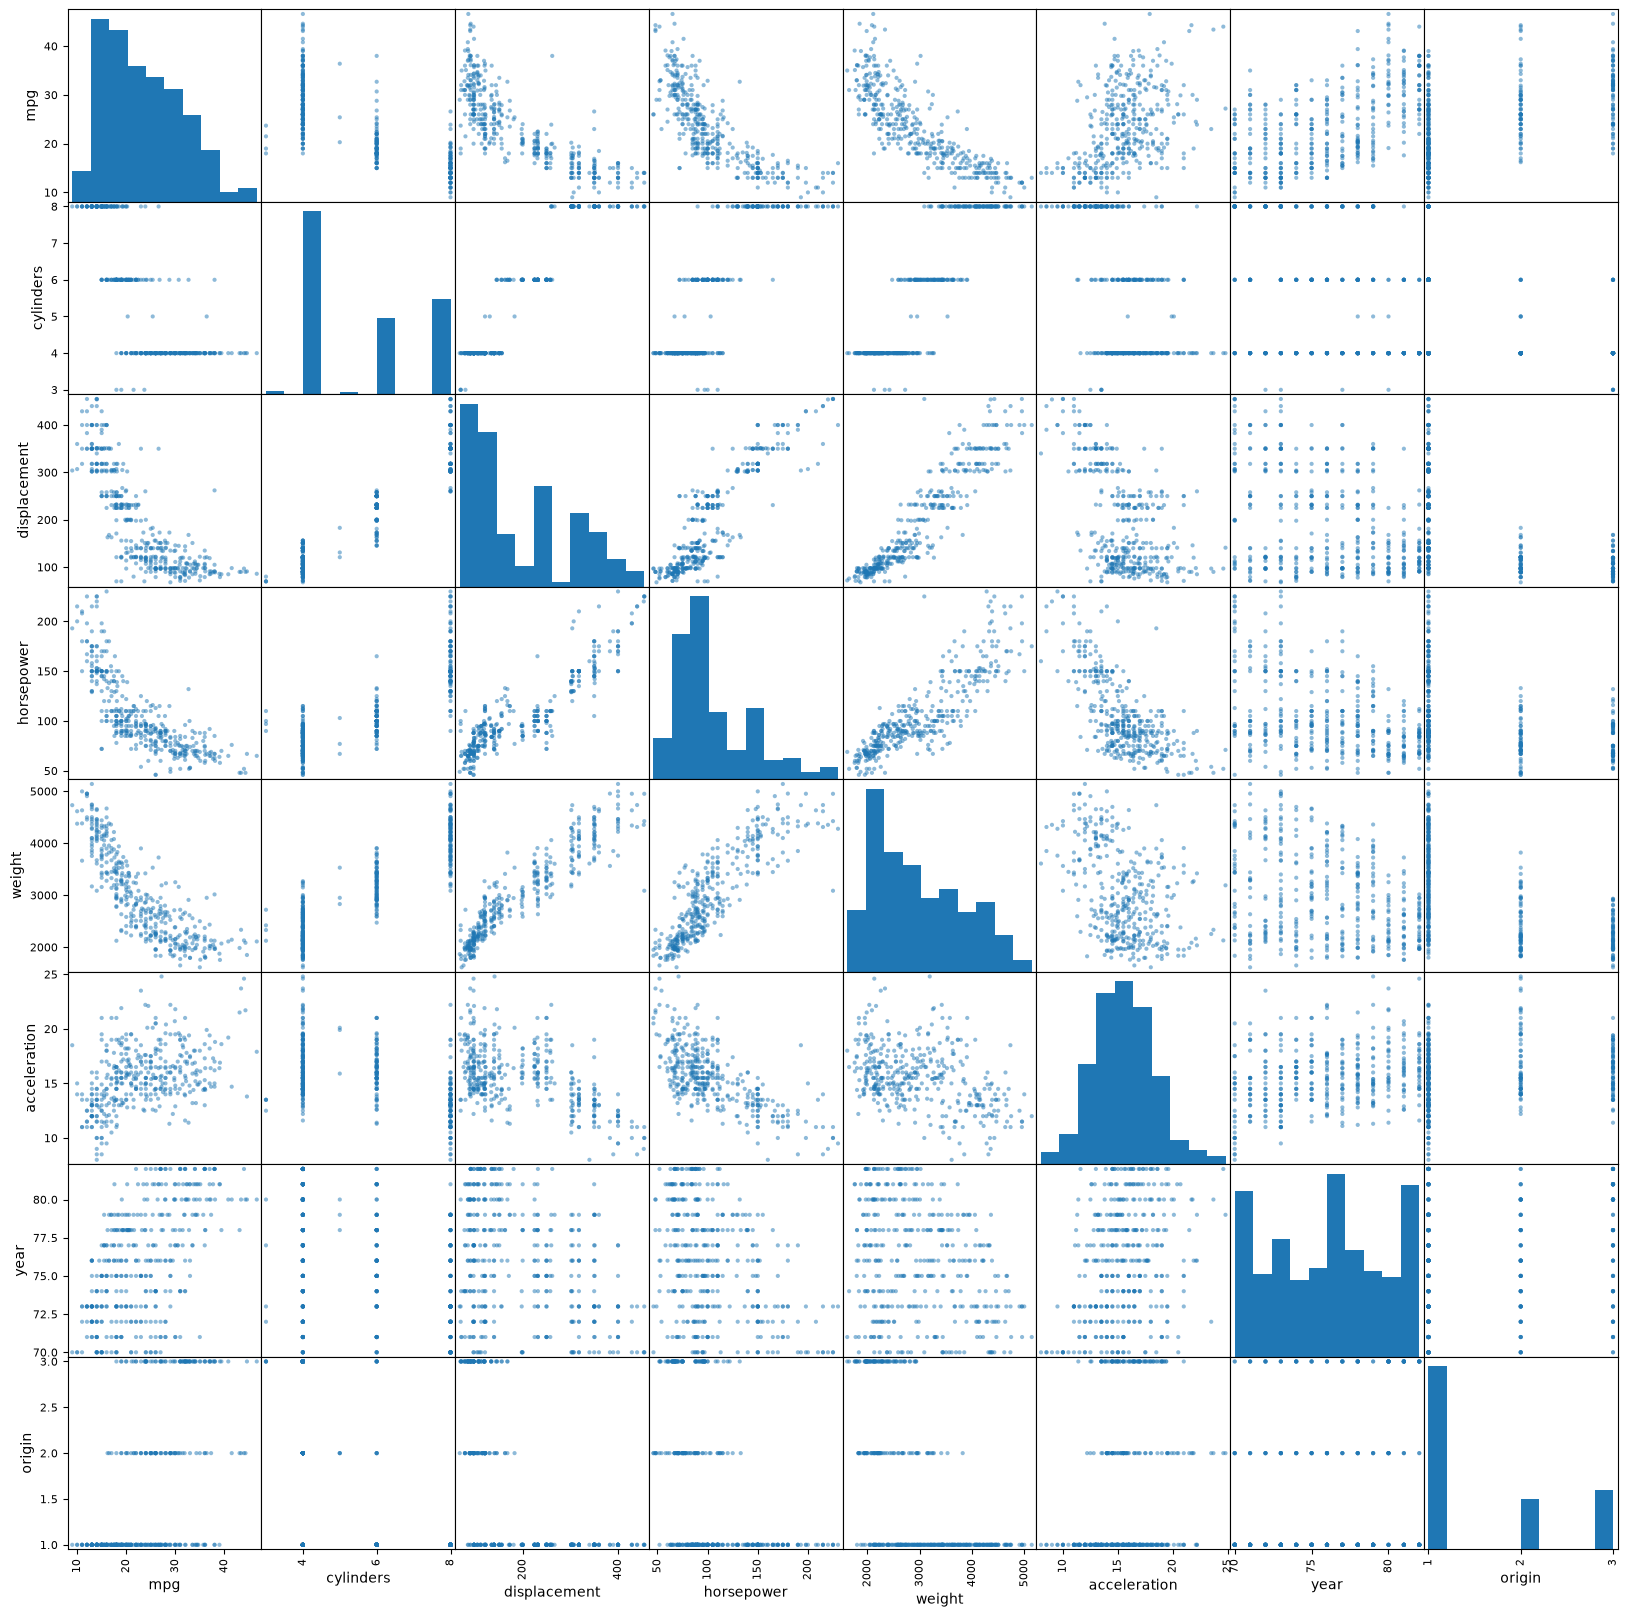

In [5]:
pd.plotting.scatter_matrix(Auto, figsize=(20,20));

To visualise the correlations between predictors, we plot a heatmap of the correlation matrix. As we can see, `cylinders`, `displacement`, `horsepower`, `weight` seem to be heavily pairwise correlated. If we use all these predictors at once in our regression model, it will likely lead to severe collinearity problems, making the coefficient estimates highly unstable.

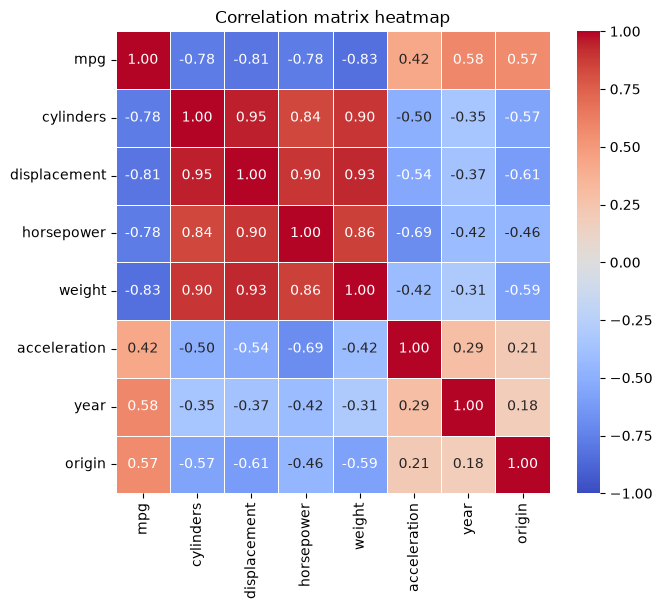

In [6]:
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    Auto.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlation matrix heatmap')
plt.show()

### Fitting a model

We first fit an ordinary least squares model with `mpg` as the response and all other variables except `name` as predictors. Since `origin` is categorical with 3 possible categories, we introduce two dummy variables `origin1` and `origin2`.

From the summary of our results, we can see that:
* The $p$-values of the coefficients for `cylinders` and `horsepower` are very high, which is to be expected due to the high correlation between `cylinders`, `horsepower`, `displacement`, and `weight`.
* The $p$-value of the coefficient for `acceleration` is also very high, so there is insufficient evidence to conclude any significant relationship between `acceleration` and `mpg`.
* The $p$-value of the coefficient for `year` is very low, and the coefficient itself is positive, which unsurprisingly suggests that the `mpg` performance of cars are improving over time.
* The coefficients for `origin1` and `origin2` are both negative, suggesting that European and Asian cars tend to have lower `mpg` than American cars. However, the $p$-value for `origin2` is much greater than $0.05$, so there Asian cars having lower `mpg` than American cars is not statistically significant.

In [7]:
Auto['origin1'] = (Auto['origin'] == 1).astype(int)
Auto['origin2'] = (Auto['origin'] == 2).astype(int)

X = Auto[Auto.columns.drop(['mpg', 'origin'])].copy()
X['constant'] = 1
y = Auto['mpg']

linear_model = sm.OLS(y, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          1.79e-139
Time:                        22:53:11   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cylinders       -0.4897      0.321     -1.524   

### Diagnostic plots

Now we make some diagnostic plots of our regression model to identify potential problems with the fit.

* The residues against fitted values plots shows a U shape, suggesting a non-linear relationship between predictors and the response.
* The studentised residuals against leverage plot reveals that our model contains quite a few outliers and high-leverage points, but there are no outliers that are also high-leverage points.
* The shape of the normal Q-Q plot indicates that the error terms are close to being normally-distributed.

In [26]:
import math
from scipy.special import erfinv

def diagnostic_plots(model):
    fitted_values = model.fittedvalues
    variance = model.scale
    residuals = model.resid
    leverage = model.get_influence().hat_matrix_diag
    residuals_studentised = model.get_influence().resid_studentized_internal

    residuals_sorted = pd.Series(residuals_studentised).sort_values(ascending=True)
    residuals_sqrt = abs(residuals_studentised) ** 0.5

    N = len(residuals_sorted)
    quantiles = [math.sqrt(2) * erfinv(2 * ((i - 0.5)/N) - 1) for i in range(N)]

    diagnostic = plt.Figure(figsize=(12,12))
    axs = diagnostic.subplots(nrows=2, ncols=2)

    axs[0][0].scatter(fitted_values, residuals, s=4)
    axs[0][0].axhline(0)
    axs[0][0].set_xlabel('Fitted Values')
    axs[0][0].set_ylabel('Residuals')
    axs[0][0].set_title('Residuals against fitted values')

    axs[0][1].scatter(quantiles, residuals_sorted, s=4)
    axs[0][1].set_xlabel('Theoretical quantiles')
    axs[0][1].set_ylabel('Sorted studentised residuals')
    axs[0][1].set_title('Normal Q-Q')

    axs[1][0].scatter(fitted_values, residuals_sqrt, s=4)
    axs[1][0].set_xlabel('Fitted Values')
    axs[1][0].set_ylabel('Square root of |studentised residuals|')
    axs[1][0].set_title('Scale against location')

    axs[1][1].scatter(leverage, residuals_studentised, s=4)
    axs[1][1].set_xlabel('Leverage')
    axs[1][1].set_ylabel('Studentised residuals')
    axs[1][1].set_title('Studentised residuals against leverage')
    axs[1][1].axvline(3 * model.df_model / N)

    return diagnostic    

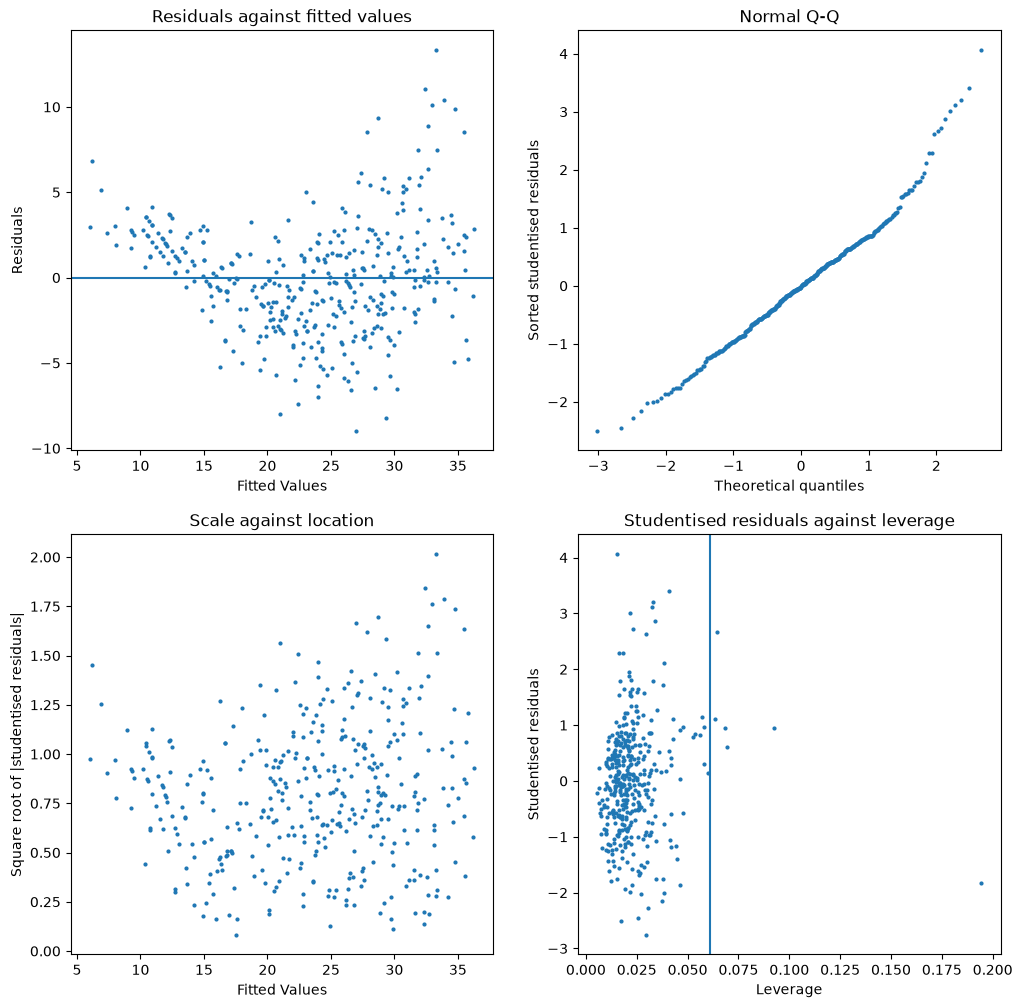

In [27]:
diagnostic_plots(linear_model)

### Interaction Terms

Some predictors from the `Auto` data set likely feature an interaction effect. For example, `horsepower` and `weight` may feature an interaction effect since a low horsepower engine will be strained if fit onto a heavy car, which could significantly decrease fuel efficiency.

The fitted model seems to support this hypothesis, judging by the low $p$-value for this interaction term. However, given the relatively small coefficient, this interaction effect is much smaller than the effects of individual predictors.

In [28]:
X1 = X.copy()
X1['weight x horsepower'] = X1['weight'] * X1['horsepower']

linear_model_interactions = sm.OLS(y, X1).fit()
print(linear_model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     268.0
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          4.69e-159
Time:                        23:31:12   Log-Likelihood:                -971.22
No. Observations:                 392   AIC:                             1962.
Df Residuals:                     382   BIC:                             2002.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cylinders              -0.0332    

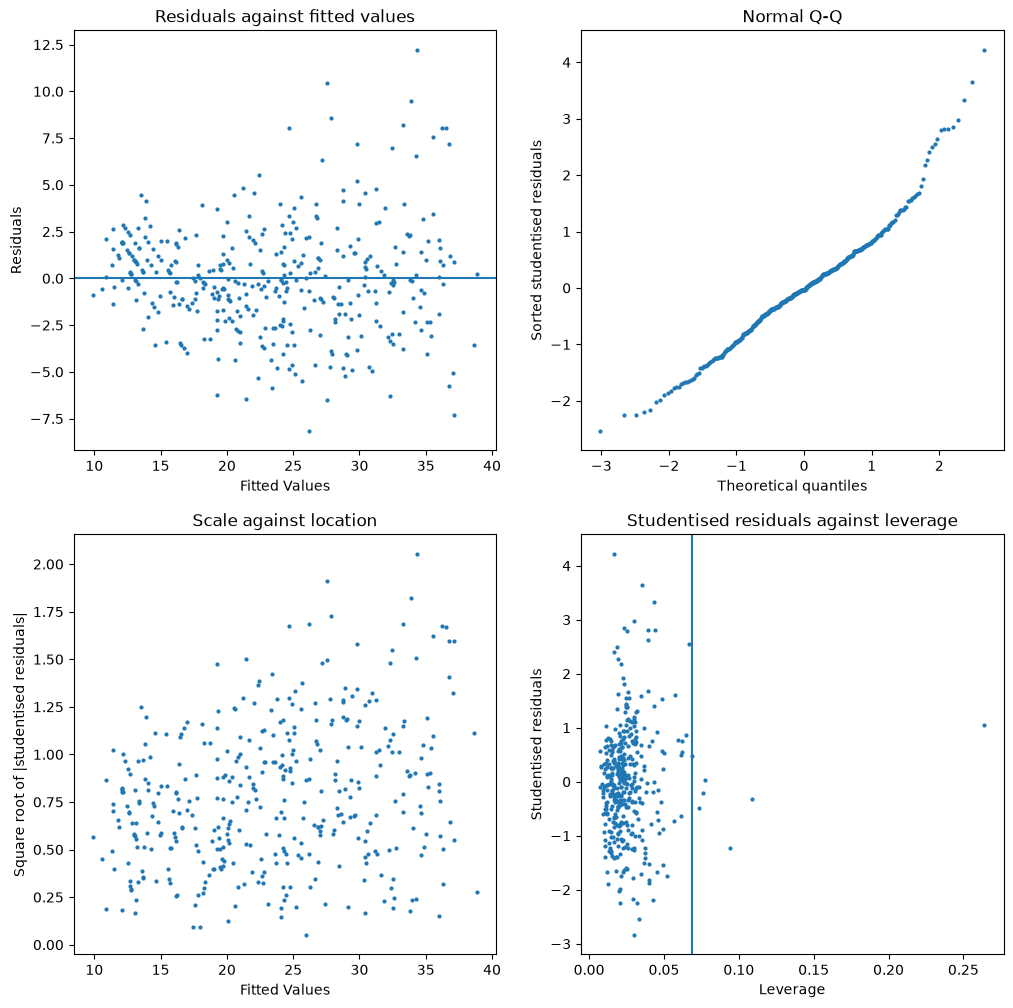

In [29]:
diagnostic_plots(linear_model_interactions)

### Non-linear relationships

Since our residual plots suggested non-linear relationships in our data, we will try to include quadratic terms in our model. Here, we added `horsepower` squared and `weight` squared.

From the results of the fit, since both quadratic terms have very small $p$-values of below $0.05$, they are statistically significant, although `weight` squared has a significantly smaller effect on `mpg` than `horsepower` squared.

The residuals against fitted values plot no longer features an obvious U shape, suggesting that the quadratic terms have improved the model's fit to the data.

In [30]:
X2 = X.copy()

X2['horsepower2'] = X2['horsepower'] ** 2
X2['weight2'] = X2['weight'] ** 2

linear_model_poly = sm.OLS(y, X2).fit()
print(linear_model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     244.2
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          6.51e-159
Time:                        23:31:12   Log-Likelihood:                -968.64
No. Observations:                 392   AIC:                             1959.
Df Residuals:                     381   BIC:                             2003.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
cylinders        0.1310      0.298      0.440   

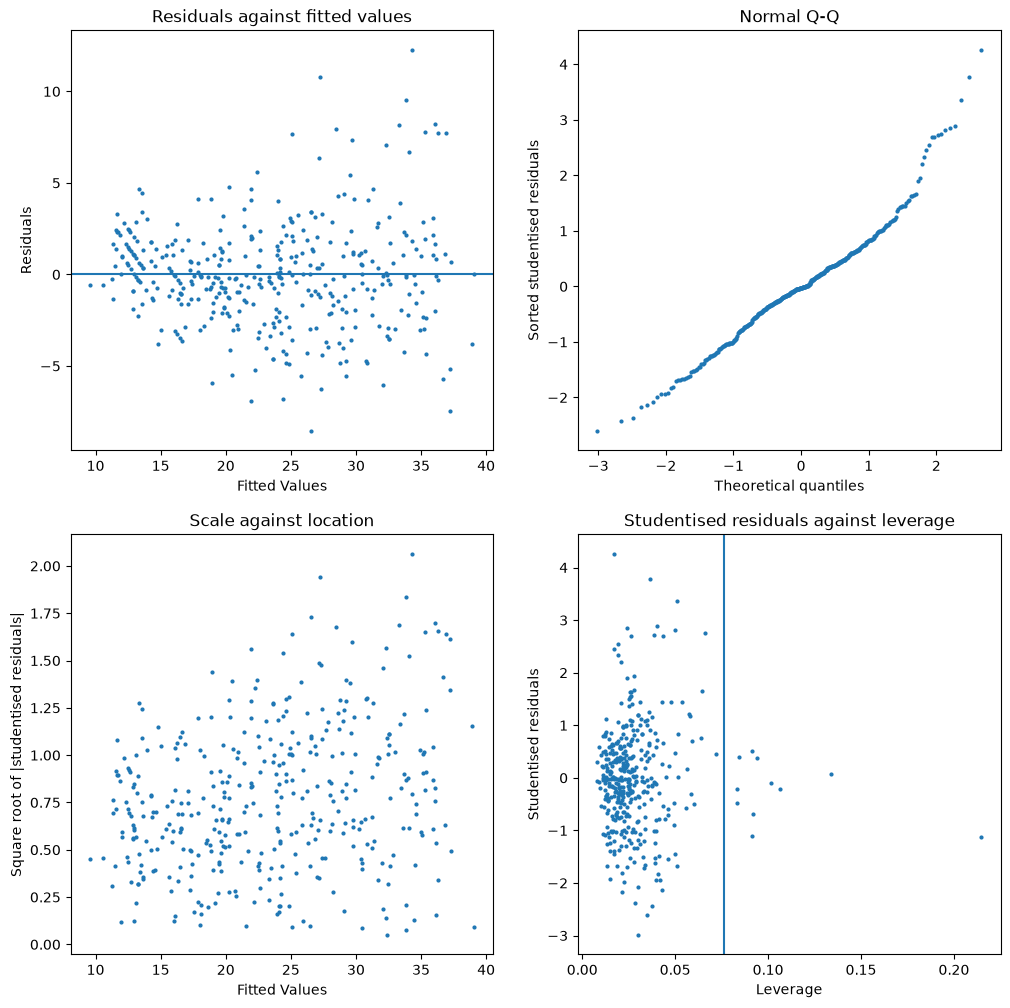

In [31]:
diagnostic_plots(linear_model_poly)

### Consolidated model

Given that our previous work revealed

* High correlations between the predictors `cylinders`, `displacement`, `horsepower`, `weight`
* Consistently high $p$-values above $0.05$ for `acceleration`
* Presence of non-linear relationships in the data,

we have opted to drop `cylinders`, `displacement`, `acceleration`, and include `weight` squared as well as `horsepower` squared to the model.

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     346.5
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          1.24e-161
Time:                        23:31:12   Log-Likelihood:                -971.13
No. Observations:                 392   AIC:                             1958.
Df Residuals:                     384   BIC:                             1990.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
horsepower     -0.1536      0.030     -5.145      

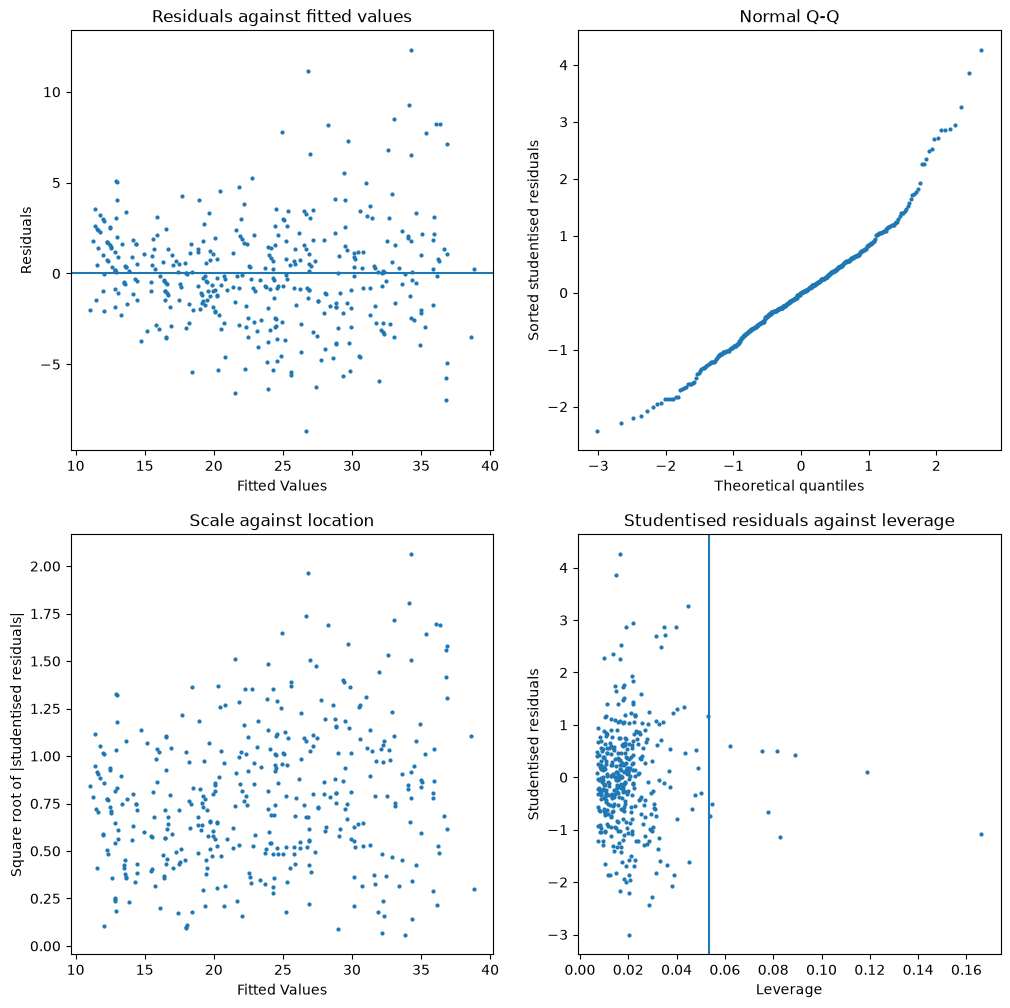

In [32]:
X3 = X[X.columns.drop(['cylinders', 'displacement', 'acceleration'])].copy()
X3['weight2'] = X3['weight'] ** 2
X3['horsepower2'] = X3['horsepower'] ** 2

linear_model_simplified = sm.OLS(y, X3).fit()
print(linear_model_simplified.summary())
diagnostic_plots(linear_model_simplified)